# Analisi dei raggi di diffrazione elettronica su grafite

Per ciascuna immagine:
1. Calibrazione scala dal disco verde (Ø = 100 mm)
2. Centro spot tramite fit gaussiano 2D
3. Profilo radiale azimutalmente mediato
4. Raggi interno/esterno al semi-massimo → raggio medio ± Δr
5. Tabella riassuntiva + grafico r vs 1/√V

In [46]:
# ============================================================
# CELLA 1 — Librerie e funzioni
# ============================================================

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter
from scipy import ndimage
import os, re

DIAMETRO_SCHERMO_MM = 100.0


def fmt(x, n=3):
    """Formatta un numero con virgola decimale (stile italiano)."""
    return f'{x:.{n}f}'.replace('.', ',')


def extract_voltage(filename):
    """Estrae la tensione in kV dal nome file (es. '3.4_kV.jpeg' → 3.4)."""
    m = re.search(r'([\d]+[._][\d]+)_?kV', filename, re.IGNORECASE)
    if m:
        return float(m.group(1).replace('_', '.'))
    return None


def gaussian_2d(xy, amplitude, x0, y0, sigma_x, sigma_y, offset):
    """Gaussiana 2D (appiattita per curve_fit)."""
    x, y = xy
    return (offset + amplitude * np.exp(
        -((x - x0)**2 / (2 * sigma_x**2) + (y - y0)**2 / (2 * sigma_y**2))
    )).ravel()


def gaussian_peak(r, A, r0, sigma, B):
    """Gaussiana 1D + baseline."""
    return A * np.exp(-(r - r0)**2 / (2 * sigma**2)) + B


def find_green_circle(image_gray, threshold=20, erosion_iter=3):
    """Rileva lo schermo verde e fitta un cerchio. Ritorna (cx, cy, R) in px."""
    mask = ndimage.binary_fill_holes(image_gray > threshold)
    labeled, nf = ndimage.label(mask)
    sizes = ndimage.sum(mask, labeled, range(1, nf + 1))
    screen = (labeled == int(np.argmax(sizes)) + 1)
    edges = screen.astype(int) - ndimage.binary_erosion(
        screen, iterations=erosion_iter).astype(int)
    ey, ex = np.where(edges > 0)
    A_mat = np.column_stack([2*ex, 2*ey, -np.ones(len(ex))])
    params, _, _, _ = np.linalg.lstsq(A_mat, ex**2 + ey**2, rcond=None)
    a, b, c = params
    return a, b, np.sqrt(a**2 + b**2 - c)


def find_center(image, roi_radius=30):
    """Centro sub-pixel via fit gaussiano 2D. Ritorna (col, riga, σ_col, σ_riga)."""
    coords = np.unravel_index(np.argmax(image), image.shape)
    row0, col0 = coords
    r = roi_radius
    r_min, r_max = max(0, row0-r), min(image.shape[0], row0+r)
    c_min, c_max = max(0, col0-r), min(image.shape[1], col0+r)
    roi = image[r_min:r_max, c_min:c_max].astype(float)
    ny, nx = roi.shape
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
    p0 = [roi.max()-roi.min(), nx/2., ny/2., r/3., r/3., roi.min()]
    try:
        popt, pcov = curve_fit(gaussian_2d, (X, Y), roi.ravel(),
                               p0=p0, maxfev=10000)
        perr = np.sqrt(np.diag(pcov))
        return popt[1]+c_min, popt[2]+r_min, perr[1], perr[2]
    except RuntimeError:
        return float(col0), float(row0), np.nan, np.nan


def radial_profile(image, center):
    """Profilo radiale azimutalmente mediato."""
    x0, y0 = center
    Y, X = np.mgrid[0:image.shape[0], 0:image.shape[1]]
    R_int = np.sqrt((X - x0)**2 + (Y - y0)**2).astype(int)
    s = np.bincount(R_int.ravel(), weights=image.ravel().astype(float))
    n = np.bincount(R_int.ravel())
    m = n > 0; I = np.zeros_like(s); I[m] = s[m] / n[m]
    return np.arange(len(I)), I


def find_half_max_radii(r_data, I_data):
    """Raggi interno/esterno al semi-massimo con baseline laterali indipendenti."""
    idx_pk = np.argmax(I_data); pv = I_data[idx_pk]
    bl_in  = I_data[:idx_pk+1].min() if idx_pk > 0 else I_data[0]
    bl_out = I_data[idx_pk:].min() if idx_pk < len(I_data)-1 else I_data[-1]
    hm_in  = bl_in  + (pv - bl_in)  / 2.0
    hm_out = bl_out + (pv - bl_out) / 2.0
    r_in = r_out = np.nan
    for k in range(idx_pk):
        if I_data[k] <= hm_in < I_data[k+1]:
            f = (hm_in - I_data[k]) / (I_data[k+1] - I_data[k])
            r_in = r_data[k] + f*(r_data[k+1] - r_data[k]); break
    for k in range(idx_pk, len(I_data)-1):
        if I_data[k] > hm_out >= I_data[k+1]:
            f = (hm_out - I_data[k]) / (I_data[k+1] - I_data[k])
            r_out = r_data[k] + f*(r_data[k+1] - r_data[k]); break
    return r_in, r_out


def analyze_image(file_path, voltage_kV=None, show_plots=True):
    """Pipeline completa per una singola immagine."""
    basename = os.path.basename(file_path)
    if voltage_kV is None:
        voltage_kV = extract_voltage(basename)
    print(f'\n{"="*70}')
    print(f'  {basename}  —  V = {fmt(voltage_kV, 2)} kV')
    print(f'{"="*70}')

    img = Image.open(file_path)
    rgb = np.array(img)
    gray = np.array(img.convert('L'))

    scx, scy, sR = find_green_circle(gray)
    mm_px = DIAMETRO_SCHERMO_MM / (2 * sR)
    print(f'  Schermo: Ø = {fmt(2*sR,1)} px = 100 mm  →  {fmt(mm_px,6)} mm/px')

    cx, cy, _, _ = find_center(gray)
    print(f'  Centro diffrazione: ({fmt(cx,1)}; {fmt(cy,1)}) px')

    ra, Ia = radial_profile(gray, (cx, cy))
    Is = savgol_filter(Ia, window_length=31, polyorder=3)

    smk = (ra >= 50) & (ra <= 400)
    rs, Is2 = ra[smk], Is[smk]
    pk, _ = find_peaks(Is2, prominence=0.5, width=5, distance=20)
    print(f'  Picchi trovati: {len(pk)}')

    results = []
    for i, p in enumerate(pk):
        rp = rs[p]
        mf = (ra >= rp-20) & (ra <= rp+20)
        rf = ra[mf].astype(float); If = Ia[mf].astype(float); Ifs = Is[mf]
        if len(rf) < 5: continue
        try:
            popt, _ = curve_fit(
                gaussian_peak, rf, If,
                p0=[If.max()-If.min(), rp, 5., If.min()],
                bounds=([0, rp-20, 0.5, 0], [np.inf, rp+20, 30, np.inf]),
                maxfev=10000)
            r0_fit = popt[1]; sig_fit = abs(popt[2])
            r_in, r_out = find_half_max_radii(rf, Ifs)
            hwhm = sig_fit * np.sqrt(2 * np.log(2))
            if np.isnan(r_in):  r_in  = r0_fit - hwhm
            if np.isnan(r_out): r_out = r0_fit + hwhm
            r_med = (r_in + r_out) / 2.0; dr = (r_out - r_in) / 2.0
            res = {
                'ring': i+1,
                'r_inner_px': r_in,  'r_outer_px': r_out,
                'r_medio_px': r_med, 'delta_r_px': dr,
                'r_inner_mm': r_in*mm_px, 'r_outer_mm': r_out*mm_px,
                'r_medio_mm': r_med*mm_px, 'delta_r_mm': dr*mm_px,
            }
            results.append(res)
            print(f'  Ring {i+1}: r = {fmt(r_med*mm_px)} ± {fmt(dr*mm_px)} mm')
        except RuntimeError as e:
            print(f'  ⚠ Ring {i+1}: fit fallito — {e}')

    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax = axes[0]
        ax.plot(ra, Ia, 'b-', alpha=0.3, linewidth=0.8)
        ax.plot(ra, Is, 'b-', linewidth=1.5)
        for r in results:
            ax.axvline(r['r_medio_px'], color='red', linestyle='-', alpha=0.7)
            ax.axvline(r['r_inner_px'], color='red', linestyle='--', alpha=0.4)
            ax.axvline(r['r_outer_px'], color='red', linestyle='--', alpha=0.4)
        ax.set_xlim(0, 450); ax.set_xlabel('Raggio (px)'); ax.set_ylabel('Intensità')
        ax.set_title(f'{fmt(voltage_kV,2)} kV — Profilo radiale')
        ax.grid(True, alpha=0.3)
        ax = axes[1]
        ax.imshow(rgb)
        ax.scatter(cx, cy, c='white', marker='+', s=200, linewidths=2)
        cols = ['cyan', 'magenta', 'yellow']
        for j, r in enumerate(results):
            c = cols[j % len(cols)]
            lbl = f'R{r["ring"]}: {fmt(r["r_medio_mm"],2)}±{fmt(r["delta_r_mm"],2)} mm'
            ax.add_patch(patches.Circle((cx,cy), r['r_medio_px'],
                fill=False, edgecolor=c, linewidth=2, label=lbl))
            ax.add_patch(patches.Circle((cx,cy), r['r_inner_px'],
                fill=False, edgecolor=c, linewidth=0.8, linestyle='--'))
            ax.add_patch(patches.Circle((cx,cy), r['r_outer_px'],
                fill=False, edgecolor=c, linewidth=0.8, linestyle='--'))
        ax.set_title(f'{fmt(voltage_kV,2)} kV — Anelli')
        ax.legend(loc='upper right', fontsize=8)
        plt.tight_layout(); plt.show()

    return {'voltage_kV': voltage_kV, 'mm_per_px': mm_px, 'rings': results}


print('Funzioni definite ✓')

Funzioni definite ✓



  3.4_kV.jpeg  —  V = 3,40 kV
  Schermo: Ø = 1245,9 px = 100 mm  →  0,080264 mm/px
  Centro diffrazione: (851,4; 688,3) px
  Picchi trovati: 2
  Ring 1: r = 15,423 ± 0,757 mm
  Ring 2: r = 27,391 ± 1,054 mm


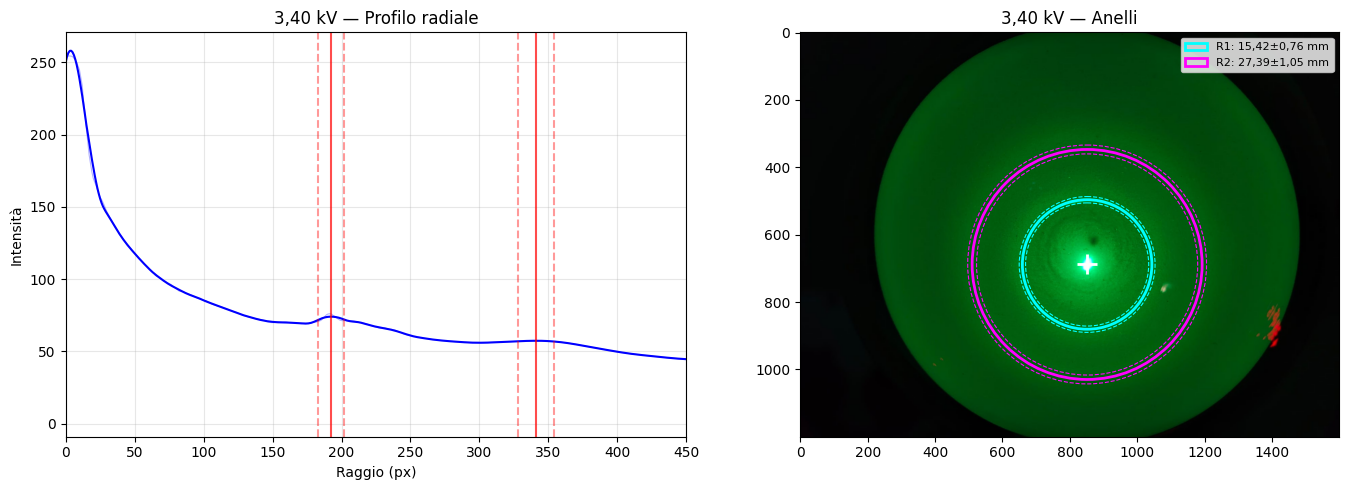


  3.8_kV.jpeg  —  V = 3,80 kV
  Schermo: Ø = 1247,9 px = 100 mm  →  0,080135 mm/px
  Centro diffrazione: (855,2; 679,1) px
  Picchi trovati: 2
  Ring 1: r = 14,837 ± 0,876 mm
  Ring 2: r = 25,056 ± 1,086 mm


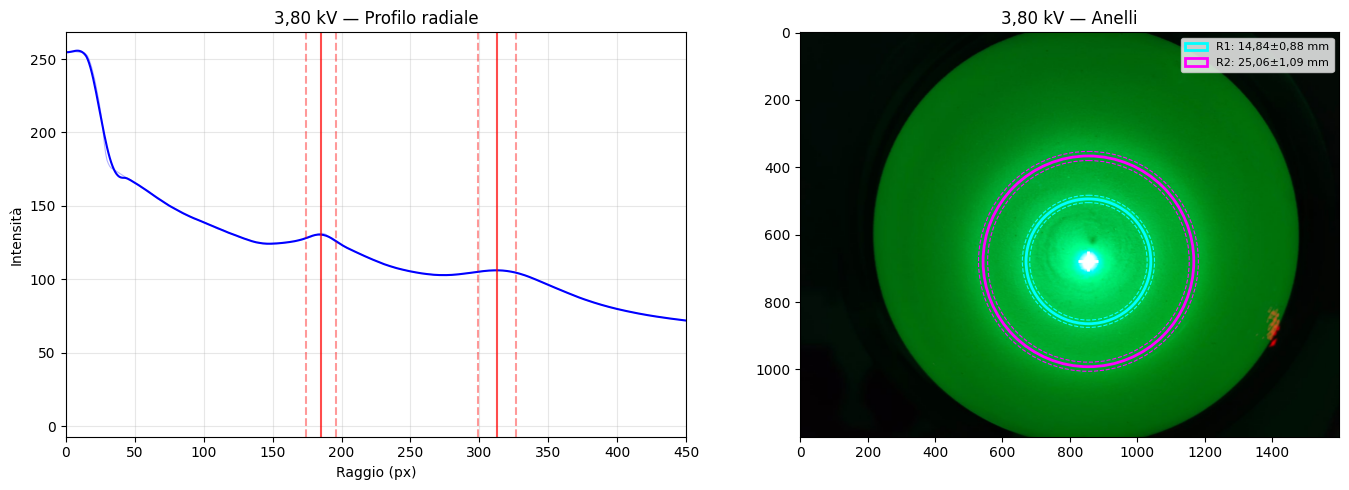


  4.1_kV.jpeg  —  V = 4,10 kV
  Schermo: Ø = 1249,2 px = 100 mm  →  0,080050 mm/px
  Centro diffrazione: (876,1; 674,5) px
  Picchi trovati: 2
  Ring 1: r = 14,148 ± 0,965 mm
  Ring 2: r = 23,989 ± 1,065 mm


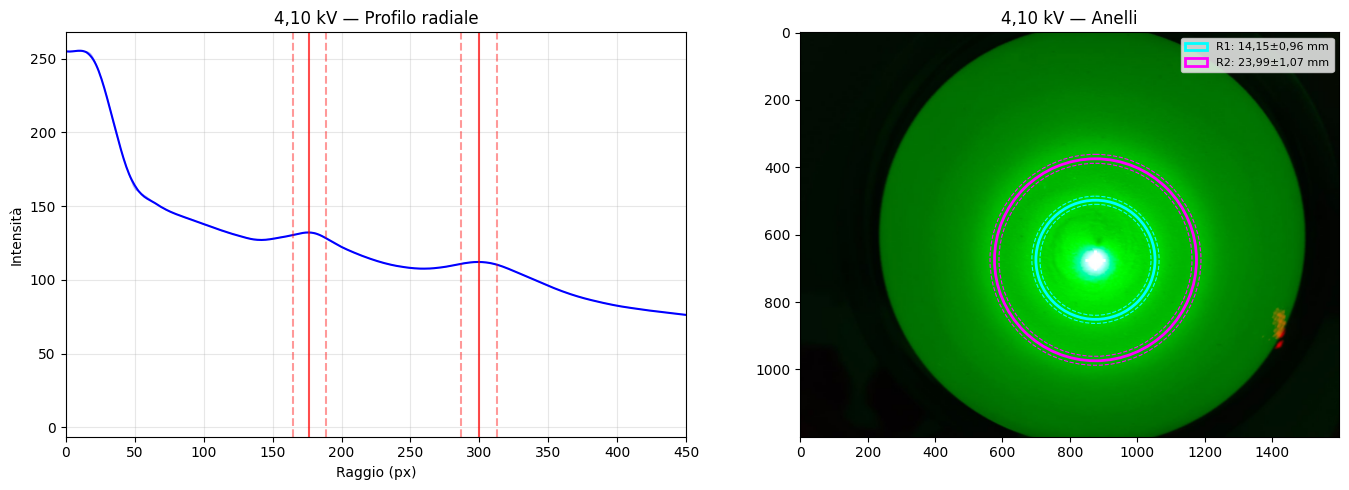


  4.35_kV.jpeg  —  V = 4,35 kV
  Schermo: Ø = 1243,9 px = 100 mm  →  0,080394 mm/px
  Centro diffrazione: (885,2; 678,2) px
  Picchi trovati: 2
  Ring 1: r = 14,296 ± 0,947 mm
  Ring 2: r = 24,011 ± 1,058 mm


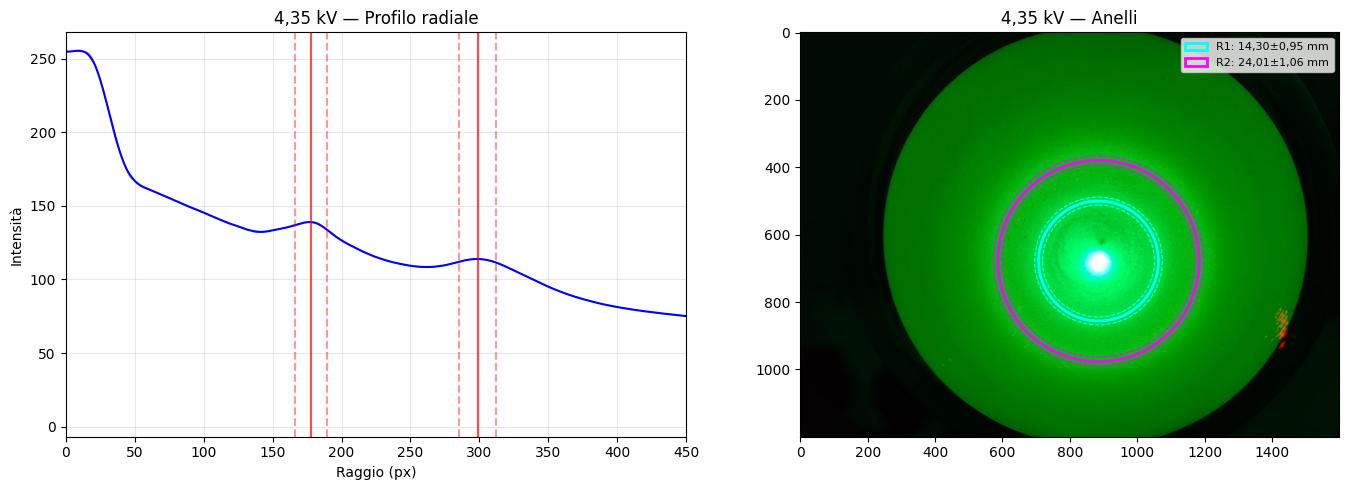


  4.5_kV.jpeg  —  V = 4,50 kV
  Schermo: Ø = 1249,5 px = 100 mm  →  0,080031 mm/px
  Centro diffrazione: (886,7; 662,4) px
  Picchi trovati: 2
  Ring 1: r = 13,847 ± 0,957 mm
  Ring 2: r = 22,966 ± 1,053 mm


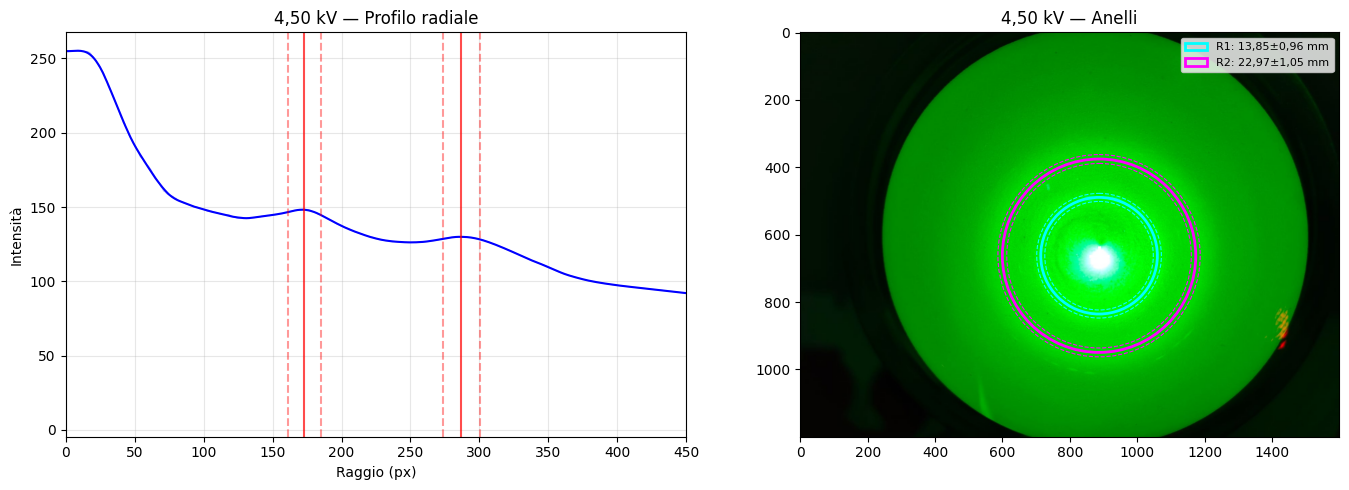

In [47]:
# ============================================================
# CELLA 2 — Analisi di tutte le immagini
# ============================================================

percorso_foto = os.path.join('..', 'Foto')

immagini = [
    ('3.4_kV.jpeg',  3.4),
    ('3.8_kV.jpeg',  3.8),
    ('4.1_kV.jpeg',  4.1),
    ('4.35_kV.jpeg', 4.35),
    ('4.5_kV.jpeg',  4.5),
]

all_results = []
for nome, V in immagini:
    path = os.path.join(percorso_foto, nome)
    res = analyze_image(path, V, show_plots=True)
    all_results.append(res)


  TABELLA RIASSUNTIVA: POTENZIALE vs RAGGI DI DIFFRAZIONE
   V (kV) │ Ring │  r_int (mm) │  r_ext (mm) │ r_medio (mm) │   Δr (mm)
─────────────────────────────────────────────────────────────────────────────────────
     3,40 │    1 │      14,666 │      16,180 │       15,423 │     0,757
     3,40 │    2 │      26,336 │      28,445 │       27,391 │     1,054
─────────────────────────────────────────────────────────────────────────────────────
     3,80 │    1 │      13,960 │      15,713 │       14,837 │     0,876
     3,80 │    2 │      23,970 │      26,141 │       25,056 │     1,086
─────────────────────────────────────────────────────────────────────────────────────
     4,10 │    1 │      13,183 │      15,113 │       14,148 │     0,965
     4,10 │    2 │      22,924 │      25,054 │       23,989 │     1,065
─────────────────────────────────────────────────────────────────────────────────────
     4,35 │    1 │      13,349 │      15,244 │       14,296 │     0,947
     4,35 │    2 │   

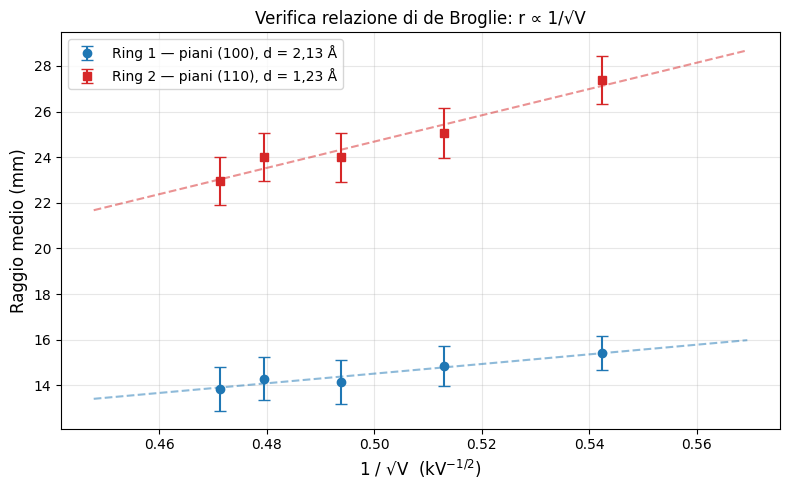


Risultati salvati in: risultati_diffrazione.csv (separatore: punto e virgola, decimale: virgola)


In [48]:
# ============================================================
# CELLA 3 — Tabella riassuntiva + grafico r vs 1/√V
# ============================================================

# --- Tabella con virgola decimale ---
print('\n' + '='*85)
print('  TABELLA RIASSUNTIVA: POTENZIALE vs RAGGI DI DIFFRAZIONE')
print('='*85)
print(f'{"V (kV)":>9} │ {"Ring":>4} │ {"r_int (mm)":>11} │ {"r_ext (mm)":>11} │ '
      f'{"r_medio (mm)":>12} │ {"Δr (mm)":>9}')
print('─'*85)

for res in all_results:
    V = res['voltage_kV']
    for r in res['rings']:
        print(f'{fmt(V,2):>9} │ {r["ring"]:4d} │ {fmt(r["r_inner_mm"]):>11} │ '
              f'{fmt(r["r_outer_mm"]):>11} │ {fmt(r["r_medio_mm"]):>12} │ '
              f'{fmt(r["delta_r_mm"]):>9}')
    print('─'*85)

# --- Tabella compatta ---
print('\n── Formato compatto ──')
print(f'{"V (kV)":>9}  {"r₁ (mm)":>11}  {"Δr₁ (mm)":>10}  {"r₂ (mm)":>11}  {"Δr₂ (mm)":>10}')
for res in all_results:
    V = res['voltage_kV']
    rings = res['rings']
    if len(rings) >= 2:
        print(f'{fmt(V,2):>9}  {fmt(rings[0]["r_medio_mm"]):>11}  {fmt(rings[0]["delta_r_mm"]):>10}  '
              f'{fmt(rings[1]["r_medio_mm"]):>11}  {fmt(rings[1]["delta_r_mm"]):>10}')
    elif len(rings) == 1:
        print(f'{fmt(V,2):>9}  {fmt(rings[0]["r_medio_mm"]):>11}  {fmt(rings[0]["delta_r_mm"]):>10}  '
              f'{"—":>11}  {"—":>10}')

# --- Rapporto r2/r1 ---
print('\n── Rapporto r₂/r₁ (atteso ≈ √3 ≈ 1,732) ──')
for res in all_results:
    rings = res['rings']
    if len(rings) >= 2:
        ratio = rings[1]['r_medio_mm'] / rings[0]['r_medio_mm']
        print(f'  V = {fmt(res["voltage_kV"],2)} kV:  r₂/r₁ = {fmt(ratio, 4)}')

# --- Grafico: r vs 1/√V (relazione di de Broglie) ---
# λ ∝ 1/√V  e  r ∝ λ  →  r ∝ 1/√V
# Se la relazione è corretta, r vs 1/√V deve essere lineare
print('\n── Verifica relazione di de Broglie: r ∝ 1/√V ──')

fig, ax = plt.subplots(figsize=(8, 5))

for ring_idx, (color, marker, label) in enumerate([
    ('tab:blue', 'o', 'Ring 1 — piani (100), d = 2,13 Å'),
    ('tab:red', 's', 'Ring 2 — piani (110), d = 1,23 Å')
]):
    V_list, r_list, dr_list = [], [], []
    for res in all_results:
        if len(res['rings']) > ring_idx:
            V_list.append(res['voltage_kV'])
            r_list.append(res['rings'][ring_idx]['r_medio_mm'])
            dr_list.append(res['rings'][ring_idx]['delta_r_mm'])

    V_arr = np.array(V_list)
    r_arr = np.array(r_list)
    dr_arr = np.array(dr_list)
    inv_sqrtV = 1.0 / np.sqrt(V_arr)

    ax.errorbar(inv_sqrtV, r_arr, yerr=dr_arr, fmt=marker, color=color,
                capsize=4, markersize=6, label=label)

    # Fit lineare r = m / √V + q
    if len(V_arr) >= 2:
        coeffs = np.polyfit(inv_sqrtV, r_arr, 1)
        x_fit = np.linspace(inv_sqrtV.min()*0.95, inv_sqrtV.max()*1.05, 100)
        ax.plot(x_fit, np.polyval(coeffs, x_fit), '--', color=color, alpha=0.5)
        print(f'  {label}: r = {fmt(coeffs[0],2)} / √V + {fmt(coeffs[1],2)}')

ax.set_xlabel('1 / √V  (kV$^{-1/2}$)', fontsize=12)
ax.set_ylabel('Raggio medio (mm)', fontsize=12)
ax.set_title('Verifica relazione di de Broglie: r ∝ 1/√V')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Export CSV ---
csv_path = 'risultati_diffrazione.csv'
with open(csv_path, 'w') as f:
    f.write('V_kV;Ring;r_int_mm;r_ext_mm;r_medio_mm;delta_r_mm\n')
    for res in all_results:
        for r in res['rings']:
            f.write(f'{fmt(res["voltage_kV"],2)};{r["ring"]};'
                    f'{fmt(r["r_inner_mm"])};{fmt(r["r_outer_mm"])};'
                    f'{fmt(r["r_medio_mm"])};{fmt(r["delta_r_mm"])}\n')
print(f'\nRisultati salvati in: {csv_path} (separatore: punto e virgola, decimale: virgola)')